In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader

In [3]:
df = pd.read_csv("GRASIM.csv")

In [4]:
df.shape

(5306, 15)

In [5]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,GRASIM,EQ,405.80,429.9,438.3,425.00,438.3,438.30,432.24,101578,4.390621e+12,NaN,NaN,NaN
1,2000-01-04,GRASIM,EQ,438.30,437.5,440.0,420.05,439.5,437.15,428.27,126117,5.401216e+12,NaN,NaN,NaN
2,2000-01-05,GRASIM,EQ,437.15,420.1,447.9,412.00,430.0,439.60,436.10,163877,7.146660e+12,NaN,NaN,NaN
3,2000-01-06,GRASIM,EQ,439.60,449.9,474.8,449.90,474.8,474.80,474.68,44248,2.100384e+12,NaN,NaN,NaN
4,2000-01-07,GRASIM,EQ,474.80,472.0,512.8,472.00,512.8,512.80,512.61,188564,9.666049e+12,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Symbol              5306 non-null   object 
 2   Series              5306 non-null   object 
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4797 non-null   float64
 14  %Deliverble         4797 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 621.9

In [7]:
#sort the dataset according to date-time
df["Date"] = pd.to_datetime(df["Date"].astype(str), errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

In [8]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,GRASIM,EQ,405.80,429.9,438.3,425.00,438.3,438.30,432.24,101578,4.390621e+12,NaN,NaN,NaN
1,2000-01-04,GRASIM,EQ,438.30,437.5,440.0,420.05,439.5,437.15,428.27,126117,5.401216e+12,NaN,NaN,NaN
2,2000-01-05,GRASIM,EQ,437.15,420.1,447.9,412.00,430.0,439.60,436.10,163877,7.146660e+12,NaN,NaN,NaN
3,2000-01-06,GRASIM,EQ,439.60,449.9,474.8,449.90,474.8,474.80,474.68,44248,2.100384e+12,NaN,NaN,NaN
4,2000-01-07,GRASIM,EQ,474.80,472.0,512.8,472.00,512.8,512.80,512.61,188564,9.666049e+12,NaN,NaN,NaN


In [9]:
df = df.drop_duplicates()

numeric_df = df[
    ["Prev Close","Open","High","Low","Last","Close",
     "VWAP","Volume","Turnover","Trades","Deliverable Volume"]
]

In [10]:
numeric_df.shape

(5306, 11)

In [11]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,405.80,429.9,438.3,425.00,438.3,438.30,432.24,101578,4.390621e+12,NaN,NaN
1,438.30,437.5,440.0,420.05,439.5,437.15,428.27,126117,5.401216e+12,NaN,NaN
2,437.15,420.1,447.9,412.00,430.0,439.60,436.10,163877,7.146660e+12,NaN,NaN
3,439.60,449.9,474.8,449.90,474.8,474.80,474.68,44248,2.100384e+12,NaN,NaN
4,474.80,472.0,512.8,472.00,512.8,512.80,512.61,188564,9.666049e+12,NaN,NaN


In [12]:
#performing data cleaning
numeric_df.isna().sum()

Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
dtype: int64

In [ ]:
#filling missing values using linear interpolation

numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()

In [14]:
numeric_df.isna().sum()

Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

In [15]:
numeric_df.duplicated().sum()

np.int64(0)

In [16]:
#convert df to numpy
feature_names = numeric_df.columns.tolist()
num_features = df.shape[1]
print("Features used:", feature_names)

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']


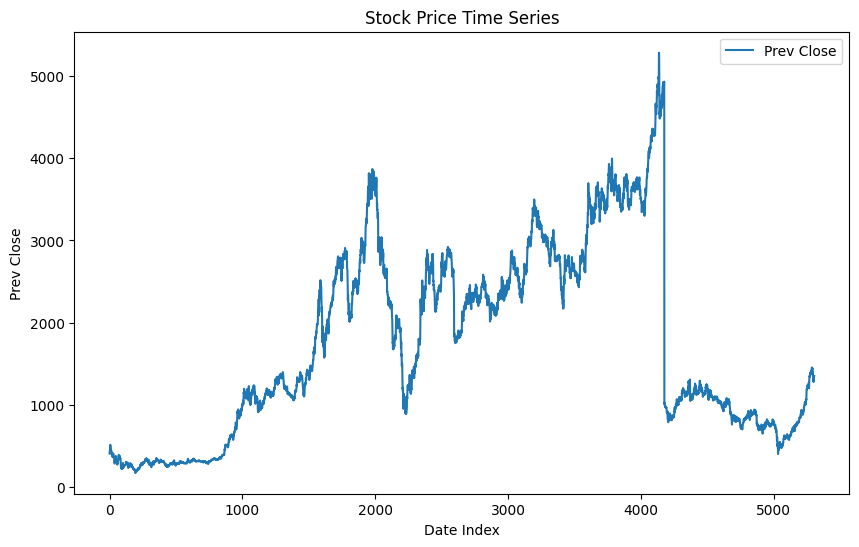

In [17]:
#vizualizing time series

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(numeric_df.index, numeric_df[feature_names[0]], label=feature_names[0])

plt.title('Stock Price Time Series')
plt.xlabel('Date Index')
plt.ylabel(feature_names[0])
plt.legend()
plt.show()

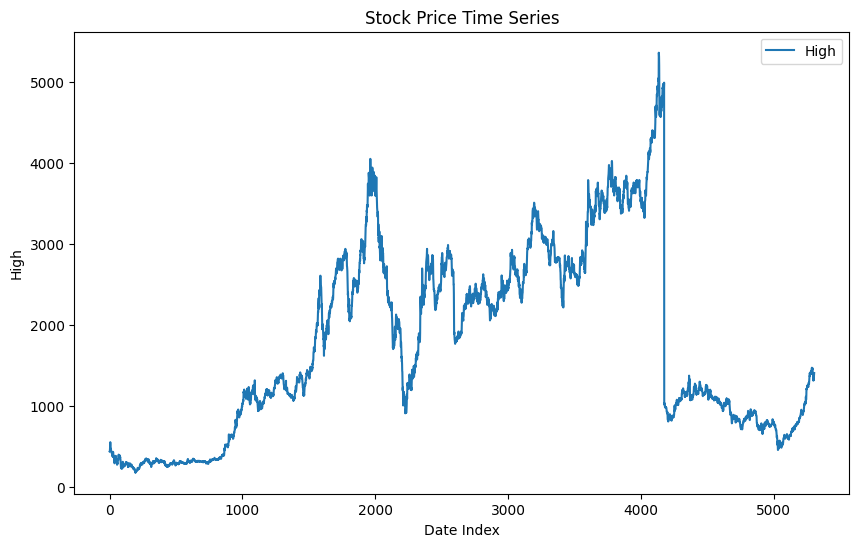

In [18]:

plt.figure(figsize=(10, 6))
plt.plot(numeric_df.index, numeric_df[feature_names[2]], label=feature_names[2])
plt.title('Stock Price Time Series')
plt.xlabel('Date Index')
plt.ylabel(feature_names[2])
plt.legend()
plt.show()

In [19]:
import numpy as np
data = numeric_df.values.astype(np.float32)   #convert df to numpy
print("Data shape:", data.shape)

Data shape: (5306, 11)


In [20]:
data

array([[4.0579999e+02, 4.2989999e+02, 4.3829999e+02, ..., 4.3906213e+12,
        2.1110000e+03, 5.1193000e+04],
       [4.3829999e+02, 4.3750000e+02, 4.4000000e+02, ..., 5.4012160e+12,
        2.1110000e+03, 5.1193000e+04],
       [4.3714999e+02, 4.2010001e+02, 4.4789999e+02, ..., 7.1466604e+12,
        2.1110000e+03, 5.1193000e+04],
       ...,
       [1.3312000e+03, 1.3374500e+03, 1.3490000e+03, ..., 1.7165110e+14,
        3.3235000e+04, 6.1838600e+05],
       [1.3411500e+03, 1.3544000e+03, 1.3695000e+03, ..., 2.4181434e+14,
        5.2053000e+04, 8.7217900e+05],
       [1.3507000e+03, 1.3420000e+03, 1.4074000e+03, ..., 4.5211165e+14,
        8.7943000e+04, 1.4450170e+06]], shape=(5306, 11), dtype=float32)

In [21]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5
TRAIN_RATIO = 0.8
BATCH_SIZE = 4

In [22]:
#train-test split
split_idx = int(len(data) * TRAIN_RATIO)
train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)
train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

In [23]:
train_data.shape, test_data.shape, val_data.shape

((3395, 11), (1062, 11), (849, 11))

In [24]:
#data normalization

from sklearn.preprocessing import normalize
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

In [25]:
#Time series chunking into input-output pairs for supervised learning

def create_sequences(data_array, input_steps=10, output_steps=5, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <=0 :
        raise ValueError("Overlap must be smaller than input steps")

    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps: i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [26]:
#prepairing train-test data with chunking

X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)


print("X_train: ", X_train.shape, "y_train: ", y_train.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)
print("X_val: ", X_val.shape, "y_val: ", y_val.shape)

X_train:  (1691, 10, 11) y_train:  (1691, 5, 11)
X_test:  (524, 10, 11) y_test:  (524, 5, 11)
X_val:  (418, 10, 11) y_val:  (418, 5, 11)


In [27]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [28]:
#defining Tensor dataset and dataloader

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
#defining model

import torch.nn as nn
class LSTMForecaster(nn.Module):
    def __init__(self):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(11, 10, batch_first=True)
        self.fc = nn.Linear(10, 5 * 11)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [31]:
model = LSTMForecaster().to(device)
lr=0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [32]:
#method for training

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [33]:
#method for evaluation

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)

            loss = criterion(preds, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [34]:
#simple training(without early stopping)

EPOCHS = 100
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch [1/100] | Train Loss: 0.028110 | Val Loss: 0.015408
Epoch [2/100] | Train Loss: 0.006717 | Val Loss: 0.002316
Epoch [3/100] | Train Loss: 0.000715 | Val Loss: 0.000817
Epoch [4/100] | Train Loss: 0.000156 | Val Loss: 0.000654
Epoch [5/100] | Train Loss: 0.000110 | Val Loss: 0.000603
Epoch [6/100] | Train Loss: 0.000105 | Val Loss: 0.000579
Epoch [7/100] | Train Loss: 0.000101 | Val Loss: 0.000578
Epoch [8/100] | Train Loss: 0.000098 | Val Loss: 0.000539
Epoch [9/100] | Train Loss: 0.000095 | Val Loss: 0.000526
Epoch [10/100] | Train Loss: 0.000092 | Val Loss: 0.000533
Epoch [11/100] | Train Loss: 0.000088 | Val Loss: 0.000513
Epoch [12/100] | Train Loss: 0.000083 | Val Loss: 0.000472
Epoch [13/100] | Train Loss: 0.000078 | Val Loss: 0.000444
Epoch [14/100] | Train Loss: 0.000073 | Val Loss: 0.000418
Epoch [15/100] | Train Loss: 0.000067 | Val Loss: 0.000391
Epoch [16/100] | Train Loss: 0.000062 | Val Loss: 0.000381
Epoch [17/100] | Train Loss: 0.000057 | Val Loss: 0.000353
Epoch 

In [35]:
model = LSTMForecaster().to(device)
lr=0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [36]:
#training with early stopping based on validation loss

EPOCHS = 100
PATIENCE = 10
train_losses = []
val_losses = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss :.6f} | Val Loss: {val_loss :.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Epoch [1/100] | Train Loss: 0.025774 | Val Loss: 0.014919
Epoch [2/100] | Train Loss: 0.006197 | Val Loss: 0.001706
Epoch [3/100] | Train Loss: 0.000398 | Val Loss: 0.000594
Epoch [4/100] | Train Loss: 0.000112 | Val Loss: 0.000577
Epoch [5/100] | Train Loss: 0.000102 | Val Loss: 0.000550
Epoch [6/100] | Train Loss: 0.000098 | Val Loss: 0.000533
Epoch [7/100] | Train Loss: 0.000095 | Val Loss: 0.000518
Epoch [8/100] | Train Loss: 0.000093 | Val Loss: 0.000502
Epoch [9/100] | Train Loss: 0.000092 | Val Loss: 0.000508
Epoch [10/100] | Train Loss: 0.000091 | Val Loss: 0.000516
Epoch [11/100] | Train Loss: 0.000090 | Val Loss: 0.000506
Epoch [12/100] | Train Loss: 0.000089 | Val Loss: 0.000504
Epoch [13/100] | Train Loss: 0.000088 | Val Loss: 0.000491
Epoch [14/100] | Train Loss: 0.000087 | Val Loss: 0.000484
Epoch [15/100] | Train Loss: 0.000086 | Val Loss: 0.000473
Epoch [16/100] | Train Loss: 0.000085 | Val Loss: 0.000478
Epoch [17/100] | Train Loss: 0.000084 | Val Loss: 0.000474
Epoch 

In [37]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [38]:
#evaluation of model on test dataset

test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)
print("Test Loss: ", test_loss )

Test Loss:  0.0001731522240424271


In [39]:
predictions.shape, targets.shape

((524, 5, 11), (524, 5, 11))

In [40]:
predictions

array([[[0.02802946, 0.02812686, 0.02889339, ..., 0.02528962,
         0.0165548 , 0.01495804],
        [0.02869758, 0.02911231, 0.02801064, ..., 0.02502048,
         0.01443388, 0.01512809],
        [0.03006101, 0.02839231, 0.02582934, ..., 0.0224711 ,
         0.02237439, 0.01477881],
        [0.02867564, 0.0279115 , 0.02810927, ..., 0.02074248,
         0.01672911, 0.01446982],
        [0.02801907, 0.02832857, 0.02883946, ..., 0.01949592,
         0.01793908, 0.01459233]],

       [[0.03099261, 0.02731674, 0.03151499, ..., 0.03617485,
         0.01673978, 0.01816022],
        [0.02993813, 0.03027992, 0.02591905, ..., 0.03187957,
         0.0143592 , 0.02312586],
        [0.03637846, 0.02931682, 0.02529763, ..., 0.02550879,
         0.02986972, 0.02457719],
        [0.03662876, 0.02991211, 0.02661112, ..., 0.0235986 ,
         0.02238641, 0.01958006],
        [0.02637151, 0.02522977, 0.03213012, ..., 0.02238561,
         0.02483474, 0.01939135]],

       [[0.02843602, 0.02924757, 0.0

In [41]:
preds_2d = predictions.reshape(-1, predictions.shape[-1])
targets_2d = targets.reshape(-1, targets.shape[-1])
preds_2d.shape, targets_2d.shape

((2620, 11), (2620, 11))

In [42]:
#performance of model using metrics(MSE, RMSE, MAE)

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(targets_2d, preds_2d)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_2d, preds_2d)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.00017315220611635596
RMSE: 0.013158731174256732
MAE: 0.005037447437644005


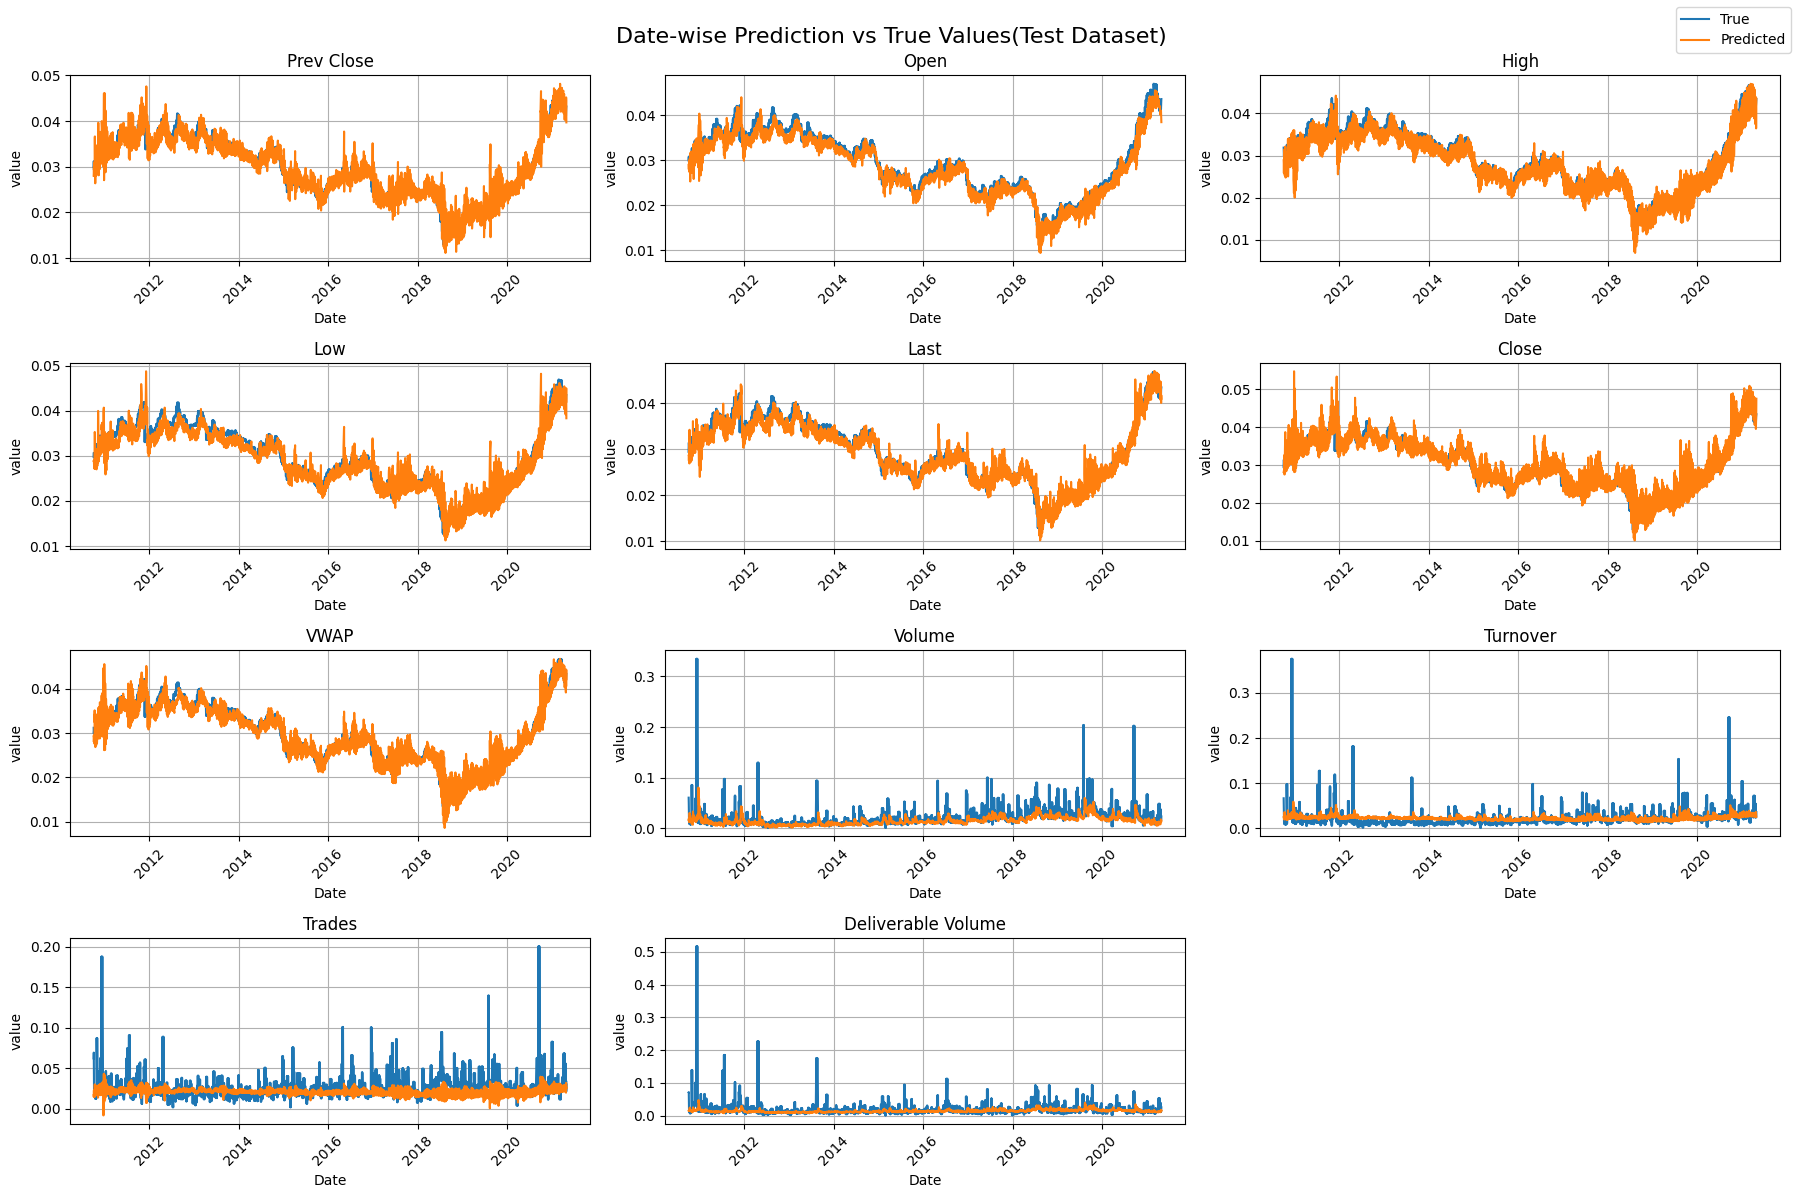

In [ ]:
#datewise prediction v/s True labels on test dataset

import matplotlib.pyplot as plt

num_features = predictions.shape[-1]

# date-wise values
dates = pd.to_datetime(df["Date"], errors="coerce")

# align dates with prediction length
plot_dates = dates[-len(targets.reshape(-1, 11)):].reset_index(drop=True)

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle("Date-wise Prediction vs True Values(Test Dataset) ",fontsize=16)
for i in range(num_features):

    pred_feature = predictions[:, :, i].reshape(-1)
    true_feature = targets[:, :, i].reshape(-1)

    axes[i].plot(
        plot_dates,
        true_feature,
        label="True"
    )

    axes[i].plot(
        plot_dates,
        pred_feature,
        label="Predicted"
    )

    axes[i].set_title(feature_names[i])
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("value")

    axes[i].tick_params(axis='x', rotation=45)

    axes[i].grid(True)

fig.delaxes(axes[-1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()